In [1]:
import os
import re
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

CLASS_MAP = {
    'A': 'Adenocarcinoma',
    'B': 'Small Cell Carcinoma',
    'E': 'Large Cell Carcinoma',
    'G': 'Squamous Cell Carcinoma',
}

def safe_load_nifti(path):
    """Load NIfTI volume data, handling VoidDType / RGB / slope-intercept issues.
    
    Some NIfTI files from dcm2niix have unset scl_slope/scl_inter (None),
    which causes DTypePromotionError with numpy >=2.0 when nibabel tries
    to apply scaling. This function falls back to raw dataobj loading.
    """
    img = nib.load(path)
    try:
        # Try standard loading
        data = img.get_fdata(dtype=np.float32)
    except Exception:
        # Fallback: load raw data without applying scaling first
        try:
            raw_data = np.array(img.dataobj)
        except Exception:
            raise

        # Handle RGB / structured arrays (e.g. from secondary captures)
        if raw_data.dtype.names is not None:
             # If it has named fields (like R, G, B)
             if 'R' in raw_data.dtype.names:
                 # Assume grayscale content in RGB container, take Red channel
                 data = raw_data['R'].astype(np.float32)
             else:
                 # Fallback for other structured types: take first field
                 data = raw_data[raw_data.dtype.names[0]].astype(np.float32)
        else:
            # Standard scalar data
            data = raw_data.astype(np.float32)
            
    return img, data
ROOT_DIR = "/home/data/Lung-PET-CT-Dx"

def parse_filename(filepath):
    """Parse patient ID, class letter, and series UID from filename.
    
    Naming convention: Lung_Dx-{Letter}{Number}_{series_uid}.nii.gz
    """
    basename = os.path.basename(filepath)
    # Remove extension(s)
    name = basename.replace('.nii.gz', '').replace('.nii', '').replace('.json', '')
    
    # Extract patient_id (e.g., Lung_Dx-A0001) and series_uid
    match = re.match(r'(Lung_Dx-([A-Z])(\d+))_(.*)', name)
    if match:
        patient_id = match.group(1)       # e.g., Lung_Dx-A0001
        class_letter = match.group(2)      # e.g., A
        patient_num = match.group(3)       # e.g., 0001
        series_uid = match.group(4)        # e.g., 1.3.6.1...
        diagnosis = CLASS_MAP.get(class_letter, 'Unknown')
        return patient_id, class_letter, patient_num, series_uid, diagnosis
    return None, None, None, None, None


def discover_data(root_dir):
    """Find all NIfTI volumes and their paired JSON metadata files."""
    nii_files = sorted(glob.glob(os.path.join(root_dir, "*.nii.gz")))
    
    records = []
    for nii_path in nii_files:
        patient_id, class_letter, patient_num, series_uid, diagnosis = parse_filename(nii_path)
        if patient_id is None:
            continue
        
        # Find matching JSON
        json_path = nii_path.replace('.nii.gz', '.json')
        has_json = os.path.exists(json_path)
        
        records.append({
            'patient_id': patient_id,
            'class_letter': class_letter,
            'patient_num': patient_num,
            'series_uid': series_uid,
            'diagnosis': diagnosis,
            'volume_path': nii_path,
            'json_path': json_path if has_json else None,
            'has_json': has_json,
        })
    
    return pd.DataFrame(records)


df = discover_data(ROOT_DIR)

print(f"Total NIfTI volumes: {len(df)}")
print(f"Volumes with JSON metadata: {df['has_json'].sum()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"\n--- Class distribution (volumes) ---")
print(df['diagnosis'].value_counts().to_string())
print(f"\n--- Class distribution (patients) ---")
print(df.groupby('diagnosis')['patient_id'].nunique().to_string())
print(f"\n--- Series per patient ---")
series_per_patient = df.groupby('patient_id').size()
print(f"  Min: {series_per_patient.min()}, Max: {series_per_patient.max()}, "
      f"Median: {series_per_patient.median():.0f}, Mean: {series_per_patient.mean():.1f}")
df.head(2)

Total NIfTI volumes: 1350
Volumes with JSON metadata: 1106
Unique patients: 355

--- Class distribution (volumes) ---
diagnosis
Adenocarcinoma             1002
Squamous Cell Carcinoma     225
Small Cell Carcinoma        112
Large Cell Carcinoma         11

--- Class distribution (patients) ---
diagnosis
Adenocarcinoma             251
Large Cell Carcinoma         5
Small Cell Carcinoma        38
Squamous Cell Carcinoma     61

--- Series per patient ---
  Min: 1, Max: 14, Median: 4, Mean: 3.8


,patient_id,class_letter,patient_num,series_uid,diagnosis,volume_path,json_path,has_json
0,Lung_Dx-A0001,A,0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.213534032021...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,True
1,Lung_Dx-A0001,A,0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.257508444832...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,True


In [2]:
def extract_nifti_metadata(volume_path):
    """Extract shape and voxel spacing from a NIfTI header (fast, no data load)."""
    try:
        img = nib.load(volume_path)
        header = img.header
        shape = img.shape
        zooms = header.get_zooms()
        dtype = header.get_data_dtype()
        
        return {
            'dim_x': shape[0] if len(shape) > 0 else None,
            'dim_y': shape[1] if len(shape) > 1 else None,
            'dim_z': shape[2] if len(shape) > 2 else None,
            'n_dims': len(shape),
            'spacing_x': round(float(zooms[0]), 4) if len(zooms) > 0 else None,
            'spacing_y': round(float(zooms[1]), 4) if len(zooms) > 1 else None,
            'spacing_z': round(float(zooms[2]), 4) if len(zooms) > 2 else None,
            'dtype': str(dtype),
        }
    except Exception as e:
        print(f"Error loading {volume_path}: {e}")
        return None


print("Extracting NIfTI metadata (header only, fast)...")
nifti_records = []
for _, row in df.iterrows():
    meta = extract_nifti_metadata(row['volume_path'])
    if meta:
        meta['patient_id'] = row['patient_id']
        meta['series_uid'] = row['series_uid']
        meta['diagnosis'] = row['diagnosis']
        nifti_records.append(meta)

df_nifti = pd.DataFrame(nifti_records)
print(f"Extracted metadata from {len(df_nifti)} volumes\n")

print("=" * 60)
print("VOLUME DIMENSIONS SUMMARY")
print("=" * 60)
print(df_nifti[['dim_x', 'dim_y', 'dim_z']].describe().round(1))

print("\n" + "=" * 60)
print("VOXEL SPACING SUMMARY (mm)")
print("=" * 60)
print(df_nifti[['spacing_x', 'spacing_y', 'spacing_z']].describe().round(4))

print(f"\nUnique in-plane spacings: {df_nifti['spacing_x'].nunique()}")
print(f"Unique slice spacings: {df_nifti['spacing_z'].nunique()}")
print(f"Data types: {df_nifti['dtype'].value_counts().to_dict()}")

Extracting NIfTI metadata (header only, fast)...
Extracted metadata from 1350 volumes

VOLUME DIMENSIONS SUMMARY
        dim_x   dim_y   dim_z
count  1350.0  1350.0  1350.0
mean    481.4   481.3   183.5
std      93.6    93.3   145.6
min     200.0   200.0     1.0
25%     512.0   512.0    52.0
50%     512.0   512.0   181.0
75%     512.0   512.0   296.0
max     888.0   752.0   852.0

VOXEL SPACING SUMMARY (mm)
       spacing_x  spacing_y  spacing_z
count  1350.0000  1350.0000  1350.0000
mean      1.1234     1.1234     3.3578
std       0.9827     0.9827     5.4490
min       0.5449     0.5449     0.6250
25%       0.7031     0.7031     1.0000
50%       0.7812     0.7812     2.0299
75%       1.0000     1.0000     5.0000
max       4.0728     4.0728   141.2500

Unique in-plane spacings: 112
Unique slice spacings: 28
Data types: {'int16': 929, "[('R', 'u1'), ('G', 'u1'), ('B', 'u1')]": 288, 'uint16': 74, 'float32': 59}


In [4]:
def apply_window(data, level, width):
    """Apply CT window (level/width) and normalize to [0, 1]."""
    lo = level - width / 2
    hi = level + width / 2
    windowed = np.clip(data, lo, hi)
    windowed = (windowed - lo) / (hi - lo)
    return windowed

Searching DICOM series in /home/data/Lung-PET-CT-Dx_dicom and annotations in /home/data/Annotation_ZMapped...


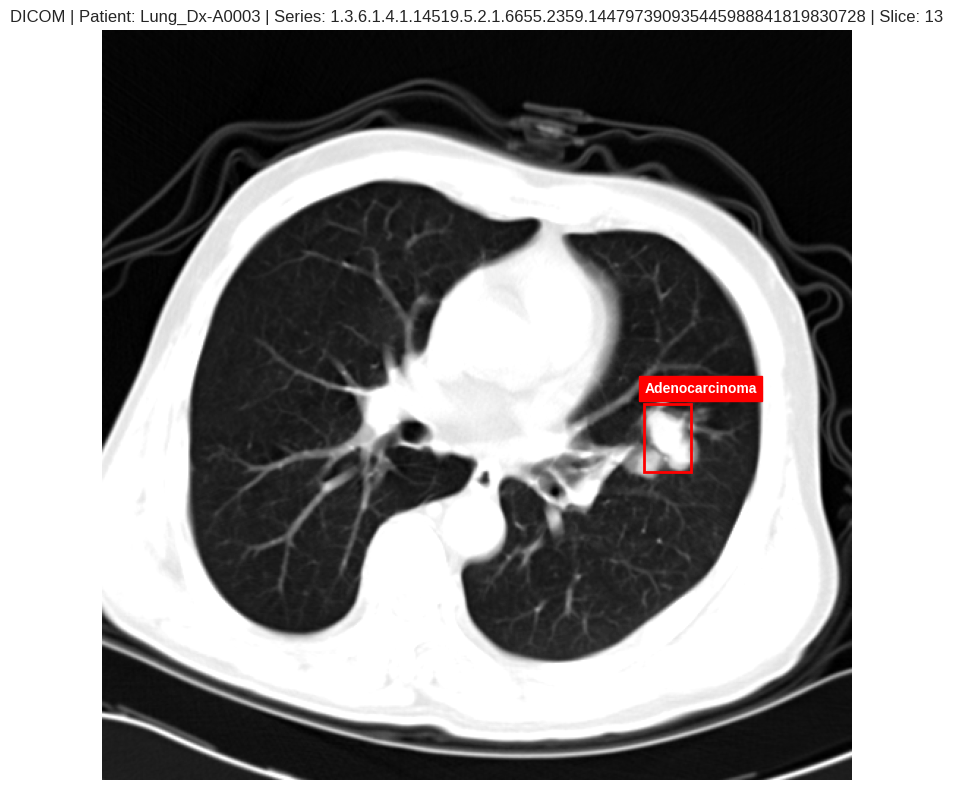

In [5]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    import pydicom
except ImportError:
    raise ImportError("pydicom is required for DICOM visualization. Install it with: pip install pydicom")

# Root directory containing DICOM files (can be changed if needed)
DICOM_ROOT_DIR = "/home/data/Lung-PET-CT-Dx_dicom"
ANNOTATION_DIR = "/home/data/Annotation_ZMapped"

def _collect_dicom_candidates(series_uid, dicom_root_dir):
    """Find candidate DICOM files for a given series UID."""
    # 1) Fast path: UID appears in file/folder names
    uid_hits = glob.glob(os.path.join(dicom_root_dir, f"**/*{series_uid}*"), recursive=True)
    dicom_files = []

    for p in uid_hits:
        if os.path.isdir(p):
            dicom_files.extend(glob.glob(os.path.join(p, "*.dcm")))
        elif p.lower().endswith(".dcm"):
            dicom_files.append(p)

    # 2) Fallback: search all .dcm and filter by SeriesInstanceUID header
    if not dicom_files:
        all_dcm = glob.glob(os.path.join(dicom_root_dir, "**/*.dcm"), recursive=True)
        for fp in all_dcm:
            try:
                ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
                if str(getattr(ds, "SeriesInstanceUID", "")) == str(series_uid):
                    dicom_files.append(fp)
            except Exception:
                continue

    return sorted(list(set(dicom_files)))

def _load_dicom_volume(dicom_files):
    """Load DICOM series into a volume array with shape [H, W, Z] in HU."""
    slices = []
    for fp in dicom_files:
        try:
            ds = pydicom.dcmread(fp, force=True)
            if not hasattr(ds, "pixel_array"):
                continue

            arr = ds.pixel_array.astype(np.float32)
            slope = float(getattr(ds, "RescaleSlope", 1.0))
            intercept = float(getattr(ds, "RescaleIntercept", 0.0))
            arr = arr * slope + intercept

            if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) >= 3:
                z_pos = float(ds.ImagePositionPatient[2])
            else:
                z_pos = float(getattr(ds, "InstanceNumber", len(slices)))

            slices.append((z_pos, arr, ds))
        except Exception:
            continue

    if not slices:
        return None

    slices.sort(key=lambda x: x[0])
    volume = np.stack([s[1] for s in slices], axis=-1)
    return volume

def visualize_dicom_slice_with_bbox(volume_path, annotation_dir, dicom_root_dir):
    """Load DICOM series for a volume and overlay XML bounding boxes on the annotated slice."""
    patient_id, class_letter, patient_num, series_uid, diagnosis = parse_filename(volume_path)
    if patient_id is None:
        return False

    short_id = patient_id.split("-")[-1]
    patient_annot_dir = os.path.join(annotation_dir, short_id)
    if not os.path.isdir(patient_annot_dir):
        return False

    xml_pattern = os.path.join(patient_annot_dir, f"*_{series_uid}_slice*.xml")
    xml_files = sorted(glob.glob(xml_pattern))
    if not xml_files:
        return False

    xml_path = xml_files[0]
    slice_str = xml_path.split("_slice")[-1].replace(".xml", "")
    slice_idx = int(slice_str)

    tree = ET.parse(xml_path)
    root = tree.getroot()
    bboxes = []
    for obj in root.findall("object"):
        name_elem = obj.find("name")
        bbox = obj.find("bndbox")
        if name_elem is None or bbox is None:
            continue
        letter = name_elem.text.strip()
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)
        bboxes.append((letter, xmin, ymin, xmax, ymax))

    if not bboxes:
        return False

    dicom_files = _collect_dicom_candidates(series_uid, dicom_root_dir)
    if not dicom_files:
        print(f"No DICOM files found for series {series_uid} in {dicom_root_dir}")
        return False

    volume = _load_dicom_volume(dicom_files)
    if volume is None:
        print("Could not load a valid DICOM volume.")
        return False

    if slice_idx >= volume.shape[2]:
        print(f"Warning: XML slice {slice_idx} out of bounds for DICOM depth {volume.shape[2]}. Using nearest valid slice.")
        slice_idx = min(slice_idx, volume.shape[2] - 1)

    slice_data = volume[:, :, slice_idx]
    slice_windowed = apply_window(slice_data, level=-700, width=1400)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(slice_windowed, cmap='gray', origin='upper')

    for letter, xmin, ymin, xmax, ymax in bboxes:
        width = xmax - xmin
        height = ymax - ymin
        class_name = CLASS_MAP.get(letter, letter)
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 8, 0), class_name, color='white', fontsize=10,
                backgroundcolor='red', fontweight='bold')

    ax.set_title(f"DICOM | Patient: {patient_id} | Series: {series_uid} | Slice: {slice_idx}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return True

print(f"Searching DICOM series in {DICOM_ROOT_DIR} and annotations in {ANNOTATION_DIR}...")
found = False
for _, row in df.iterrows():
    if row['patient_id'] == 'Lung_Dx-A0003':
        if visualize_dicom_slice_with_bbox(row['volume_path'], ANNOTATION_DIR, DICOM_ROOT_DIR):
            found = True
            break

if not found:
    print("No matching DICOM/XML pair could be visualized. Check DICOM_ROOT_DIR and ANNOTATION_DIR.")

In [7]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import pydicom
from tqdm import tqdm

DICOM_ROOT_DIR = "/home/data/Lung-PET-CT-Dx_dicom"
ANNOTATION_DIR = "/home/data/Annotation_ZMapped"
OUTPUT_DIR = "/home/data/Lung-PET-CT-Dx_dicom_annot"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Finding all annotations in {ANNOTATION_DIR}...")
xml_files = glob.glob(os.path.join(ANNOTATION_DIR, "*", "*.xml"))

series_to_xmls = {}
for xml_path in xml_files:
    basename = os.path.basename(xml_path).replace('.xml', '')
    # Format: {patient_id}_{series_uid}_slice{z_index:03d}
    
    parts = basename.split('_slice')
    if len(parts) != 2:
        continue
    
    prefix = parts[0]
    slice_idx = int(parts[1])
    
    prefix_parts = prefix.rsplit('_', 1)
    if len(prefix_parts) != 2:
        continue
        
    patient_id = prefix_parts[0]
    series_uid = prefix_parts[1]
    
    if series_uid not in series_to_xmls:
        series_to_xmls[series_uid] = []
    
    series_to_xmls[series_uid].append({
        'xml_path': xml_path,
        'slice_idx': slice_idx,
        'patient_id': patient_id
    })

print(f"Found annotations for {len(series_to_xmls)} unique series.")

for series_uid, annots in tqdm(series_to_xmls.items(), desc="Processing Series"):
    patient_id = annots[0]['patient_id']
    dicom_files = _collect_dicom_candidates(series_uid, DICOM_ROOT_DIR)
    
    if not dicom_files:
        continue
        
    # We sort DICOM slices using a similar logic to _load_dicom_volume to match the Z-mapping
    slices = []
    for fp in dicom_files:
        try:
            ds = pydicom.dcmread(fp, force=True)
            if not hasattr(ds, "pixel_array"):
                continue

            if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) >= 3:
                z_pos = float(ds.ImagePositionPatient[2])
            else:
                z_pos = float(getattr(ds, "InstanceNumber", len(slices)))

            slices.append((z_pos, ds, fp))
        except Exception:
            continue

    if not slices:
        continue

    slices.sort(key=lambda x: x[0])
        
    # Apply all annotations corresponding to this series
    for annot in annots:
        slice_idx = annot['slice_idx']
        xml_path = annot['xml_path']
        
        if slice_idx >= len(slices):
            slice_idx = min(slice_idx, len(slices) - 1)
            
        z_pos, ds, fp = slices[slice_idx]
            
        # Parse XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        bboxes = []
        for obj in root.findall("object"):
            name_elem = obj.find("name")
            bbox = obj.find("bndbox")
            if name_elem is None or bbox is None:
                continue
            letter = name_elem.text.strip()
            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))
            bboxes.append((letter, xmin, ymin, xmax, ymax))
            
        if not bboxes:
            continue
            
        # Draw bounding boxes directly in the DICOM pixel array
        pixel_array = ds.pixel_array.copy()
        
        # Find maximum value to use as the drawing color
        draw_value = pixel_array.max()
        
        for letter, xmin, ymin, xmax, ymax in bboxes:
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(pixel_array.shape[1] - 1, xmax)
            ymax = min(pixel_array.shape[0] - 1, ymax)
            
            thickness = 2
            # Draw Horizontal Lines (Top and Bottom)
            for t in range(thickness):
                if ymin + t < pixel_array.shape[0]:
                    pixel_array[ymin + t, xmin:xmax] = draw_value
                if ymax - t >= 0:
                    pixel_array[ymax - t, xmin:xmax] = draw_value
            # Draw Vertical Lines (Left and Right)
            for t in range(thickness):
                if xmin + t < pixel_array.shape[1]:
                    pixel_array[ymin:ymax, xmin + t] = draw_value
                if xmax - t >= 0:
                    pixel_array[ymin:ymax, xmax - t] = draw_value
                    
        # Update the dataset with the newly modified pixel array
        ds.PixelData = pixel_array.tobytes()
        
    # Save the entire resulting series
    series_out_dir = os.path.join(OUTPUT_DIR, patient_id, series_uid)
    os.makedirs(series_out_dir, exist_ok=True)
    
    for z_pos, ds, fp in slices:
        orig_filename = os.path.basename(fp)
        out_path = os.path.join(series_out_dir, orig_filename)
        ds.save_as(out_path)

print("Finished generating annotated DICOM images.")

Finding all annotations in /home/data/Annotation_ZMapped...
Found annotations for 820 unique series.


Processing Series:   1%|          | 8/820 [01:03<1:48:02,  7.98s/it]


KeyboardInterrupt: 

In [ ]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import pydicom
from tqdm import tqdm
import sys

DICOM_ROOT_DIR = "/home/data/Lung-PET-CT-Dx_dicom"
ANNOTATION_DIR = "/home/data/Annotation"  # Original Annotation folder, NOT Z-Mapped
OUTPUT_DIR = "/home/data/Lung-PET-CT-Dx_dicom_annot"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Mapping Patient IDs to their correct XML annotations...")
# 1. Map patient_id to XML annotations based on SOPInstanceUID
patient_xmls = {}
for patient_folder in os.listdir(ANNOTATION_DIR):
    folder_path = os.path.join(ANNOTATION_DIR, patient_folder)
    if not os.path.isdir(folder_path):
        continue
    
    xml_files = glob.glob(os.path.join(folder_path, "*.xml"))
    for xml_path in xml_files:
        # In the original Annotation folder, the filename is the exact SOPInstanceUID of the correct slice
        sop_uid = os.path.basename(xml_path).replace('.xml', '')
        if patient_folder not in patient_xmls:
            patient_xmls[patient_folder] = {}
        patient_xmls[patient_folder][sop_uid] = xml_path

print(f"Found annotations for {len(patient_xmls)} patients.")

# 2. Iterate through all DICOM series
dicom_series_dirs = [os.path.join(DICOM_ROOT_DIR, d) for d in os.listdir(DICOM_ROOT_DIR) if os.path.isdir(os.path.join(DICOM_ROOT_DIR, d))]

for series_dir in tqdm(dicom_series_dirs, desc="Processing DICOM Series"):
    series_uid = os.path.basename(series_dir)
    
    dicom_files = glob.glob(os.path.join(series_dir, "*.dcm"))
    if not dicom_files:
        continue
        
    # Read the first DICOM to determine the PatientID
    try:
        first_ds = pydicom.dcmread(dicom_files[0], stop_before_pixels=True)
        if not hasattr(first_ds, 'PatientID'):
            continue
            
        full_patient_id = str(first_ds.PatientID)  # e.g., Lung_Dx-A0001
        patient_folder = full_patient_id.split("-")[-1]  # e.g., A0001
    except Exception:
        continue
        
    # Read all DICOMs in this series to find the exact matching SOPInstanceUIDs
    slices = []
    series_has_annotation = False
    
    for fp in dicom_files:
        try:
            ds = pydicom.dcmread(fp, force=True)
            if not hasattr(ds, "pixel_array"):
                continue
                
            sop_uid = str(ds.SOPInstanceUID)
            
            # Match the exact DICOM slice by SOPInstanceUID instead of relying on Z-index mapping
            xml_path = None
            if patient_folder in patient_xmls and sop_uid in patient_xmls[patient_folder]:
                xml_path = patient_xmls[patient_folder][sop_uid]
                series_has_annotation = True
                
            # Maintain spatial ordering (optional, but good for sequential files)
            if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) >= 3:
                z_pos = float(ds.ImagePositionPatient[2])
            else:
                z_pos = float(getattr(ds, "InstanceNumber", len(slices)))
                
            slices.append((z_pos, ds, fp, xml_path))
        except Exception:
            continue
            
    if not slices:
        continue
        
    # Only save series that actually contain drawn annotations to avoid copying unaffected datasets
    if not series_has_annotation:
        continue
        
    slices.sort(key=lambda x: x[0])
    
    # Save the entire resulting series preserving structure
    series_out_dir = os.path.join(OUTPUT_DIR, full_patient_id, series_uid)
    os.makedirs(series_out_dir, exist_ok=True)
    not_drawn = []
    
    for z_pos, ds, fp, xml_path in slices:
        # Very important: if the original DICOM is compressed (e.g. JPEG Lossless),
        # replacing its PixelData with pure uncompressed bytes will corrupt it for viewers.
        # So we must properly decompress the dataset first!
        if hasattr(ds.file_meta, "TransferSyntaxUID") and ds.file_meta.TransferSyntaxUID.is_compressed:
            try:
                ds.decompress()
            except Exception as e:
                print(f"Failed to decompress {fp}: {e}")
                
        if xml_path:
            # Parse XML and explicitly draw over this matched slice
            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()
                bboxes = []
                for obj in root.findall("object"):
                    name_elem = obj.find("name")
                    bbox = obj.find("bndbox")
                    if name_elem is None or bbox is None:
                        continue
                    letter = name_elem.text.strip()
                    xmin = int(float(bbox.find("xmin").text))
                    ymin = int(float(bbox.find("ymin").text))
                    xmax = int(float(bbox.find("xmax").text))
                    ymax = int(float(bbox.find("ymax").text))
                    bboxes.append((letter, xmin, ymin, xmax, ymax))
                    
                if bboxes:
                    pixel_array = ds.pixel_array.copy()
                    draw_value = pixel_array.max()
                    
                    for letter, xmin, ymin, xmax, ymax in bboxes:
                        xmin = max(0, xmin)
                        ymin = max(0, ymin)
                        xmax = min(pixel_array.shape[1] - 1, xmax)
                        ymax = min(pixel_array.shape[0] - 1, ymax)
                        
                        thickness = 2
                        # Horizontal
                        for t in range(thickness):
                            if ymin + t < pixel_array.shape[0]:
                                pixel_array[ymin + t, xmin:xmax] = draw_value
                            if ymax - t >= 0:
                                pixel_array[ymax - t, xmin:xmax] = draw_value
                        # Vertical
                        for t in range(thickness):
                            if xmin + t < pixel_array.shape[1]:
                                pixel_array[ymin:ymax, xmin + t] = draw_value
                            if xmax - t >= 0:
                                pixel_array[ymin:ymax, xmax - t] = draw_value
                    
                    # Prevent endianness issues before tobytes()
                    if ds.is_little_endian != (sys.byteorder == 'little'):
                        pixel_array = pixel_array.byteswap()
                        
                    ds.PixelData = pixel_array.tobytes()
            except Exception as e:
                not_drawn.append(fp)
                print(f"Error drawing bbox on {fp}: {e}")
                
        # Save as a new DICOM file with original name
        orig_filename = os.path.basename(fp)
        out_path = os.path.join(series_out_dir, orig_filename)
        # Use pydicom default write settings for uncompressed TransferSyntax based on decompress()
        ds.save_as(out_path)

print("Finished generating annotated DICOM images perfectly matched by SOPInstanceUID.")

Mapping Patient IDs to their correct XML annotations...
Found annotations for 357 patients.


Processing DICOM Series:   1%|▏         | 19/1295 [04:50<5:25:25, 15.30s/it]


KeyboardInterrupt: 